# 📊 Análise de Componentes Principais (PCA) para Elaboração de Rankings Socioeconômicos

## 📌 Contexto do Projeto
O objetivo deste projeto é elaborar um ranking dos distritos do município de São Paulo, ordenando-os com base em indicadores socioeconômicos coletados pela prefeitura. A base de dados contém múltiplas variáveis numéricas e, para evitar uma análise isolada ou arbitrária baseada em apenas um único indicador, é utilizada a técnica de **PCA (Principal Component Analysis)** para consolidar todas as informações simultaneamente em um índice estruturado.

---

## 🧠 Fundamentos Teóricos do PCA

### 1. Definição da Técnica
O PCA é uma técnica de **aprendizado não-supervisionado**. Isso significa que os dados não possuem uma variável alvo (*target*) predefinida. Em vez de realizar previsões de valores futuros, o método executa uma **transformação matemática** nos dados originais, convertendo as variáveis em **fatores independentes (componentes principais)**.

* **Ordenação de Variância:** O primeiro fator gerado explica a maior parcela da variabilidade dos dados. O segundo fator retém a segunda maior parcela, e assim sucessivamente.
* **Limite de Componentes:** A quantidade máxima de fatores gerados é exatamente igual ao número de variáveis numéricas originais presentes no conjunto de dados.

### 2. Principais Aplicações do PCA
* **Redução de Dimensionalidade:** Substitui um grande volume de variáveis originais por apenas alguns fatores principais, reduzindo o tamanho do dataset sem perda significativa de informação.
* **Remoção de Multicolinearidade:** Elimina problemas onde as variáveis originais são excessivamente correlacionadas entre si. Os novos fatores gerados são totalmente independentes (ortogonais) e não possuem correlação mútua.
* **Elaboração de Rankings:** Permite consolidar múltiplos indicadores complexos em um índice único de pontuação para ordenação de observações.

### ⚠️ Restrições Técnicas
O algoritmo do PCA fundamenta-se estritamente na construção de uma **Matriz de Correlação**. Por consequência, a técnica **aceita apenas variáveis numéricas**. Variáveis categóricas ou textuais (como identificadores e nomes de regiões) devem ser isoladas do cálculo estatístico principal.


In [80]:
import pandas as pd


In [81]:
distritos = pd.read_csv("Dados/distritos_sp.csv")


In [82]:
distritos


,cod_ibge,distritos,renda,quota,escolaridade,idade,mortalidade,txcresc,causasext,favel,denspop
0,1,Água Rasa,1961,34.619999,7.6,32,13.86,-1.840000,52.980000,0.00,125.610001
1,12,Alto de Pinheiros,4180,75.959999,8.4,33,8.68,-2.520000,38.570000,0.69,57.560001
2,23,Anhanguera,1093,4.500000,5.8,23,15.36,18.120001,22.680000,0.00,8.570000
3,34,Aricanduva,1311,21.020000,6.8,27,18.43,-1.070000,76.220001,5.38,138.539993
4,45,Artur Alvim,1248,15.910000,7.0,27,19.73,-1.400000,67.250000,4.11,167.399994
...,...,...,...,...,...,...,...,...,...,...,...
91,92,Vila Medeiros,1405,19.760000,6.8,27,15.43,-1.410000,77.980003,2.49,188.929993
92,93,Vila Prudente,1755,32.080002,7.2,30,14.36,-2.550000,66.510002,7.43,101.440002
93,94,Vila Sônia,2970,41.410000,7.4,27,16.76,-0.900000,74.680000,14.93,80.120003
94,95,São Domingos,2047,23.510000,6.8,26,14.30,0.710000,62.349998,8.55,72.919998


In [83]:
distritos.info()

<class 'pandas.DataFrame'>
RangeIndex: 96 entries, 0 to 95
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   cod_ibge      96 non-null     int64  
 1   distritos     96 non-null     str    
 2   renda         96 non-null     int64  
 3   quota         96 non-null     float64
 4   escolaridade  96 non-null     float64
 5   idade         96 non-null     int64  
 6   mortalidade   96 non-null     float64
 7   txcresc       96 non-null     float64
 8   causasext     96 non-null     float64
 9   favel         96 non-null     float64
 10  denspop       96 non-null     float64
dtypes: float64(7), int64(3), str(1)
memory usage: 8.4 KB


In [84]:
variaveis_numericas = distritos.drop(['cod_ibge', 'distritos'], axis=1)
variaveis_numericas.corr()

,renda,quota,escolaridade,idade,mortalidade,txcresc,causasext,favel,denspop
renda,1.000000,0.920099,0.777332,0.732307,-0.519585,-0.424711,-0.462516,-0.146957,-0.019711
quota,0.920099,1.000000,0.850455,0.832737,-0.520282,-0.554767,-0.491020,-0.243010,0.057374
escolaridade,0.777332,0.850455,1.000000,0.955825,-0.582601,-0.692968,-0.606621,-0.432548,0.157673
idade,0.732307,0.832737,0.955825,1.000000,-0.553758,-0.703237,-0.615073,-0.499838,0.141469
mortalidade,-0.519585,-0.520282,-0.582601,-0.553758,1.000000,0.346049,0.422790,0.130877,-0.093018
txcresc,-0.424711,-0.554767,-0.692968,-0.703237,0.346049,1.000000,0.234472,0.281853,-0.279084
causasext,-0.462516,-0.491020,-0.606621,-0.615073,0.422790,0.234472,1.000000,0.404447,-0.045281
favel,-0.146957,-0.243010,-0.432548,-0.499838,0.130877,0.281853,0.404447,1.000000,-0.106481
denspop,-0.019711,0.057374,0.157673,0.141469,-0.093018,-0.279084,-0.045281,-0.106481,1.000000


# 📉 Calculando a Estatística KMO (Kaiser-Meyer-Olkin)

## 📌 O que é o Critério KMO?
O teste de **Kaiser-Meyer-Olkin (KMO)** é um índice estatístico que avalia se o conjunto de dados é adequado para a aplicação de uma análise fatorial ou PCA. Ele mede a consistência geral dos dados, indicando a proporção da variância das variáveis que pode ser considerada comum (atribuída a fatores compartilhados).

---

## 📊 Interpretação dos Resultados
A estatística KMO varia estritamente em um intervalo de **0 a 1**:

* **Próximos de 1:** Indicam que as variáveis compartilham um percentual de variância bastante elevado (correlações de Pearson altas). Significa que os dados estão **adequadamente ajustados** para o modelo.
* **Próximos de 0:** Decorrem de correlações de Pearson baixas entre as variáveis. Isso serve como um sinal de alerta, indicando que a análise fatorial ou PCA será **inadequada** para esse conjunto de dados.


In [85]:
from factor_analyzer.factor_analyzer import calculate_kmo


In [86]:
kmo_variaveis, kmo = calculate_kmo(variaveis_numericas)

In [87]:
kmo_variaveis

array([0.77821831, 0.81941916, 0.8560973 , 0.81750459, 0.94677797,
       0.84146713, 0.89083164, 0.78871213, 0.63275248])

In [88]:
kmo

np.float64(0.833091424182929)

# 📉 Teste de Esfericidade de Bartlett

## 📌 Objetivo do Teste
O **Teste de Esfericidade de Bartlett** avalia a adequabilidade dos dados para a análise fatorial ou PCA. Ele faz isso comparando a **matriz de correlações ($\rho$)** das variáveis originais com uma **matriz identidade ($I$)** de mesma dimensão.

* **Matriz Identidade ($I$):** É uma matriz que possui o número 1 na diagonal principal e zero em todas as outras posições. Caso nossos dados fossem iguais a ela, significaria que a correlação entre as variáveis é nula.

---

## 🔬 Hipóteses Estatísticas
O teste avalia duas hipóteses principais:

* **Hipótese Nula ($H_0$):** $\rho = I$
  A matriz de correlações é igual à matriz identidade. Indica que as variáveis **não possuem correlação significativa** entre si. Se não há correlação, a extração de fatores do PCA **não será adequada**.
* **Hipótese Alternativa ($H_1$):** $\rho \neq I$
  A matriz de correlações é significativamente diferente da matriz identidade. Indica que as variáveis **possuem correlações significativas** entre si, validando a aplicação do PCA.

---

## 🎯 Regra de Decisão (O que buscamos?)
Para podermos seguir com o PCA, o nosso objetivo é **rejeitar a Hipótese Nula ($H_0$)**. 

Na prática do código, isso é avaliado através do **p-valor (p-value)**. Buscamos um **p-valor menor que 0.05** (considerando um nível de significância clássico de 5%), o que comprova que as correlações fora da diagonal principal são estatisticamente diferentes de zero.

---

## ⚠️ Observação Metodológica Crucial
Deve-se **sempre preferir o Teste de Esfericidade de Bartlett à estatística KMO** para fins de decisão definitiva sobre a adequação global da análise fatorial ou PCA. 

* **Bartlett:** É um teste de hipóteses formal, fundamentado em uma distribuição de probabilidades determinada e níveis rígidos de significância estatística.
* **KMO:** Funciona apenas como um coeficiente (estatística descritiva), calculado sem uma distribuição de probabilidades associada, o que impossibilita a avaliação formal de um nível de significância correspondente para a tomada de decisão.


In [89]:
from factor_analyzer.factor_analyzer import calculate_bartlett_sphericity


In [90]:
qui_quadrado, p_valor = calculate_bartlett_sphericity(variaveis_numericas)

In [91]:
print(qui_quadrado)
print(p_valor)

748.1593126421544
5.607017481839493e-134


In [92]:
p_valor < 0.05


np.True_

## 📐 Aprofundamento Matemático: A Equação Característica ($Av = \lambda v$)

O PCA realiza uma transformação linear dos dados para um Crypto-sistema de coordenadas. Nesse processo, os autovetores ($v$) representam direções espaciais especiais, e os autovalores ($\lambda$) representam fatores de escala.

A relação fundamental entre eles é expressa pela equação:
$$Av = \lambda v$$

Onde:
* **$A$**: É a matriz de transformação (no caso do PCA, a **Matriz de Correlação** das variáveis).
* **$v$**: É o **Autovetor**.
* **$\lambda$**: É o **Autovalor** correspondente.

Isso significa que aplicar a transformação linear da matriz de correlação sobre o autovetor gera o mesmo resultado matemático que simplesmente multiplicar esse autovetor pelo número escalar $\lambda$. Por resumirem as propriedades essenciais da matriz de correlação, eles são a base para transformar as variáveis originais nos fatores finais.

---

### 🔬 Como encontrar os Autovalores e Autovetores?

Podemos reescrever a equação fundamental isolando os termos:
$$Av - \lambda v = 0$$

Para subtrair um número escalar ($\lambda$) de uma matriz ($A$), multiplicamos o escalar pela **Matriz Identidade ($I$)**, resultando na equação característica do sistema:
$$(A - \lambda I)v = 0$$

1. **Encontrando os Autovalores ($\lambda$):** 
   Para que o sistema possua uma solução real (onde $v \neq 0$), a matriz $(A - \lambda I)$ precisa ser **singular** (não-invertível). Por propriedade matemática, uma matriz singular possui determinante igual a zero:
   $$det(A - \lambda I) = 0$$
   Ao resolver esse determinante, obtemos um polinômio cujas raízes são os autovalores ($\lambda$) do projeto.

2. **Encontrando os Autovetores ($v$):**
   Com os autovalores calculados, basta substituir cada valor de $\lambda$ de volta na expressão $(A - \lambda I)v = 0$ para resolver o sistema de equações e encontrar o vetor $v$ associado a cada um.


In [93]:
variaveis_numericas

,renda,quota,escolaridade,idade,mortalidade,txcresc,causasext,favel,denspop
0,1961,34.619999,7.6,32,13.86,-1.840000,52.980000,0.00,125.610001
1,4180,75.959999,8.4,33,8.68,-2.520000,38.570000,0.69,57.560001
2,1093,4.500000,5.8,23,15.36,18.120001,22.680000,0.00,8.570000
3,1311,21.020000,6.8,27,18.43,-1.070000,76.220001,5.38,138.539993
4,1248,15.910000,7.0,27,19.73,-1.400000,67.250000,4.11,167.399994
...,...,...,...,...,...,...,...,...,...
91,1405,19.760000,6.8,27,15.43,-1.410000,77.980003,2.49,188.929993
92,1755,32.080002,7.2,30,14.36,-2.550000,66.510002,7.43,101.440002
93,2970,41.410000,7.4,27,16.76,-0.900000,74.680000,14.93,80.120003
94,2047,23.510000,6.8,26,14.30,0.710000,62.349998,8.55,72.919998


In [94]:
from sklearn.preprocessing import StandardScaler

In [95]:
colunas_numericas = variaveis_numericas.columns
colunas_numericas

Index(['renda', 'quota', 'escolaridade', 'idade', 'mortalidade', 'txcresc',
       'causasext', 'favel', 'denspop'],
      dtype='str')

In [96]:
padronizar = StandardScaler()
variaveis_numericas = padronizar.fit_transform(variaveis_numericas)
variaveis_numericas 

array([[ 1.08502328e-01,  1.80715140e-01,  5.23096244e-01,
         1.05541274e+00, -4.29281808e-01, -5.38805723e-01,
        -7.80681293e-01, -7.56406323e-01,  5.21804668e-01],
       [ 2.40630528e+00,  1.98438577e+00,  1.32019516e+00,
         1.28464265e+00, -1.47188596e+00, -7.33574170e-01,
        -1.40197826e+00, -6.68425227e-01, -8.57183702e-01],
       [-7.90322801e-01, -1.13342509e+00, -1.27037668e+00,
        -1.00765651e+00, -1.27369371e-01,  5.17822174e+00,
        -2.08708641e+00, -7.56406323e-01, -1.84993379e+00],
       [-5.64581006e-01, -4.12654904e-01, -2.74002674e-01,
        -9.07368417e-02,  4.90544879e-01, -3.18259087e-01,
         2.21327218e-01, -7.04087705e-02,  7.83822446e-01],
       [-6.29818314e-01, -6.35605024e-01, -7.47280632e-02,
        -9.07368417e-02,  7.52202169e-01, -4.12779054e-01,
        -1.65420498e-01, -2.32344990e-01,  1.36865133e+00],
       [ 5.20636431e-01,  1.67189899e-01,  9.21645940e-01,
         8.26182822e-01, -1.48396254e+00, -6.247330

In [97]:
dados_padronizados = pd.DataFrame(variaveis_numericas, columns = colunas_numericas)
dados_padronizados

,renda,quota,escolaridade,idade,mortalidade,txcresc,causasext,favel,denspop
0,0.108502,0.180715,0.523096,1.055413,-0.429282,-0.538806,-0.780681,-0.756406,0.521805
1,2.406305,1.984386,1.320195,1.284643,-1.471886,-0.733574,-1.401978,-0.668425,-0.857184
2,-0.790323,-1.133425,-1.270377,-1.007657,-0.127369,5.178222,-2.087086,-0.756406,-1.849934
3,-0.564581,-0.412655,-0.274003,-0.090737,0.490545,-0.318259,0.221327,-0.070409,0.783822
4,-0.629818,-0.635605,-0.074728,-0.090737,0.752202,-0.412779,-0.165420,-0.232345,1.368651
...,...,...,...,...,...,...,...,...,...
91,-0.467243,-0.467629,-0.274003,-0.090737,-0.113280,-0.415643,0.297211,-0.438909,1.804943
92,-0.104813,0.069895,0.124547,0.596953,-0.328644,-0.742167,-0.197326,0.190984,0.032016
93,1.153335,0.476964,0.323822,-0.090737,0.154416,-0.269567,0.154929,1.147301,-0.400020
94,0.197556,-0.304016,-0.274003,-0.319967,-0.340721,0.191576,-0.376687,0.333794,-0.545923


In [98]:
from sklearn.decomposition import PCA

In [99]:
n_fatores = dados_padronizados.shape[1]
n_fatores

9

In [100]:
pca = PCA(n_components = n_fatores)
pca.fit(dados_padronizados)

,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",9
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized SVD 

## 🛡️ Padronização de Dados via Z-Score

### 📌 Por que a escala das variáveis importa no PCA?
Como a construção de cada fator do PCA é uma combinação linear (uma soma ponderada) de todas as variáveis, a escala de grandeza de cada coluna impacta diretamente o resultado:

* **O Problema:** Se tivermos uma variável $X$ com valores entre $1000$ e $10000$ (ex: Renda) e uma variável $W$ com valores entre $0$ e $1$ (ex: Taxa de desemprego), os fatores serão severamente distorcidos e dominados pela escala gigante de $X$, e não porque ela seja estatisticamente mais importante para o modelo.
* **A Solução:** Os scores fatoriais (pesos) já são os responsáveis por ditar a importância real de cada variável e eles vêm da matriz de correlação (que ignora escalas). Portanto, para neutralizar o impacto artificial das escalas das colunas nos fatores finais, precisamos transformar todas as variáveis para uma mesma unidade de medida.

---

### 🔬 O Procedimento Z-Score
A metodologia recomendada para o PCA é a padronização por **Z-Score**. Ela transforma cada valor original de uma variável na sua distância equivalente em desvios-padrão em relação à média daquela coluna:

$$Z = \frac{x - \mu}{\sigma}$$

Onde:
* **$x$**: É o valor original a ser transformado.
* **$\mu$ (Mú)**: É a média daquela variável específica.
* **$\sigma$ (Sigma)**: É o desvio-padrão daquela variável específica.

Após aplicar esse cálculo coluna por coluna, todas as variáveis passam a ter **média igual a 0 e desvio-padrão igual a 1**, eliminando qualquer viés de escala. Na prática, automatizamos todo o processo utilizando a classe `StandardScaler()` da biblioteca **Scikit-Learn**.


In [101]:
pca.explained_variance_ratio_

array([0.55067008, 0.1293709 , 0.11070601, 0.08045185, 0.05881136,
       0.04425824, 0.01440763, 0.00722961, 0.00409432])

In [102]:
import plotly.express as px
import numpy as np

In [103]:
fatores = [f'F{i+1}' for i in range(n_fatores)]
fatores

['F1', 'F2', 'F3', 'F4', 'F5', 'F6', 'F7', 'F8', 'F9']

In [104]:
fig = px.bar(x = fatores, y = pca.explained_variance_ratio_, text = np.around(pca.explained_variance_ratio_, decimals = 2),
             title = 'Scree Plot')
fig.update_layout(yaxis = {'title':'Porcentagem de variância explicada', 'tickfont':{'size':15}},
                  xaxis = {'title': 'Fatores', 'tickfont':{'size':15}},
                  title = {'font':{'size':25}})
fig.show()


In [105]:
variancia_acumulada = [sum(pca.explained_variance_ratio_[0:i+1]) for i in range(n_fatores)]
variancia_acumulada

[np.float64(0.5506700772160416),
 np.float64(0.6800409820794435),
 np.float64(0.7907469955852217),
 np.float64(0.8711988432249138),
 np.float64(0.930010202543966),
 np.float64(0.9742684414070405),
 np.float64(0.9886760753033329),
 np.float64(0.9959056848263386),
 np.float64(1.0)]

In [106]:
fig = px.bar(x = fatores, y = variancia_acumulada, text = np.around(variancia_acumulada, decimals = 2),
             title = 'Scree Plot')
fig.update_layout(yaxis = {'title':'Porcentagem de variância explicada', 'tickfont':{'size':15}},
                  xaxis = {'title': 'Fatores', 'tickfont':{'size':15}},
                  title = {'font':{'size':25}})
fig.show()

In [107]:
pca.explained_variance_

array([5.00819944, 1.17659433, 1.00684206, 0.73168838, 0.53487384,
       0.40251704, 0.13103364, 0.0657514 , 0.03723672])

In [108]:
pca.explained_variance_ratio_ * n_fatores

array([4.95603069, 1.16433814, 0.99635412, 0.72406663, 0.52930223,
       0.39832415, 0.12966871, 0.06506649, 0.03684884])

In [109]:
print(sum(pca.explained_variance_))
print(sum(pca.explained_variance_ratio_ * n_fatores))

9.094736842105261
8.999999999999998


In [110]:
autovalores = pca.explained_variance_ratio_ * n_fatores

In [111]:
fatores_selecionados = ['Fator selecionado' if autovalor > 1 else 'Fator não selecionado' for autovalor in autovalores]
fatores_selecionados


['Fator selecionado',
 'Fator selecionado',
 'Fator não selecionado',
 'Fator não selecionado',
 'Fator não selecionado',
 'Fator não selecionado',
 'Fator não selecionado',
 'Fator não selecionado',
 'Fator não selecionado']

In [112]:
fig = px.bar(x = range(1,10), y = autovalores, text = np.around(autovalores, decimals = 2),
             title = 'Scree Plot', color = fatores_selecionados)
fig.update_layout(yaxis = {'title': 'Quantidade de variáveis explicadas', 'tickfont':{'size':15}},
                  xaxis = {'title': 'Autovalor', 'tickfont': {'size': 15}},
                  title = {'font':{'size':25}})
fig.show()


In [113]:
variancia_acumulada = np.cumsum(pca.explained_variance_ratio_)
resumo = pd.DataFrame({
    'Fator': fatores, 
    'Autovalor': autovalores, 
    'Variância Explicada': pca.explained_variance_ratio_, 
    'Variância acumulada': variancia_acumulada
})
resumo


,Fator,Autovalor,Variância Explicada,Variância acumulada
0,F1,4.956031,0.550670,0.550670
1,F2,1.164338,0.129371,0.680041
2,F3,0.996354,0.110706,0.790747
3,F4,0.724067,0.080452,0.871199
4,F5,0.529302,0.058811,0.930010
5,F6,0.398324,0.044258,0.974268
6,F7,0.129669,0.014408,0.988676
7,F8,0.065066,0.007230,0.995906
8,F9,0.036849,0.004094,1.000000


## 📊 O Gráfico de Sedimentação (Scree Plot)

### 📌 O que é?
O **Scree Plot** é uma ferramenta gráfica utilizada na análise multivariada para visualizar os autovalores de cada um dos fatores gerados pelo PCA, ordenados do maior para o menor. Ele serve como o principal guia visual para determinar quantos componentes principais devem ser retidos na análise.

A visualização pode ser construída de diferentes formas:
* Gráfico de linhas descendentes (formato clássico).
* Gráfico de barras com os autovalores absolutos.
* Gráfico de barras com a porcentagem de variância explicada (individual ou acumulada).

---

### 🦴 O Teste do "Cotovelo" (*Elbow Method*)
O método tradicional de escolha consiste em buscar graficamente o ponto de inflexão ou **"cotovelo"** da curva, onde os autovalores começam a se nivelar e formar uma linha quase horizontal. 
* **Regra:** Todos os fatores que estão posicionados **à esquerda** desse ponto de nivelamento são considerados altamente significativos e devem ser mantidos.

---

### ⚖️ O Critério de Kaiser (Raiz Latente)
Por depender de uma avaliação puramente visual, o teste do cotovelo é frequentemente criticado por sua subjetividade (um gráfico pode apresentar múltiplos pontos de inflexão). 

Para tornar a decisão matemática e consistente, o Scree Plot geralmente é acompanhado de uma **linha horizontal de corte no valor 1**. Esse é o **Critério de Kaiser**, que dita uma regra clara:
* Mantemos apenas os fatores cujo autovalor ($\lambda$) seja **maior que 1** ($\lambda > 1$). 
* Fatores com autovalor menor que 1 explicam menos variância do que uma única variável original padronizada isolada, sendo descartados.



In [114]:
pca.components_

array([[ 0.37378561,  0.40454585,  0.43416448,  0.431286  , -0.29453553,
        -0.31298937, -0.29942197, -0.20536447,  0.0746924 ],
       [-0.34194215, -0.20986443,  0.02279207,  0.06065282,  0.16369471,
        -0.31272645,  0.04069338, -0.41039975,  0.73495343],
       [ 0.17295765,  0.15501444,  0.00935731, -0.06348322, -0.17379496,
        -0.27775581,  0.43911857,  0.68814007,  0.41015077],
       [ 0.06339126,  0.13996332,  0.08458471,  0.12690816,  0.58019562,
        -0.45311541,  0.49035151, -0.1587924 , -0.38148578],
       [ 0.34200389,  0.27796072,  0.00388393, -0.03140668,  0.68113225,
         0.35010444, -0.28968662,  0.14639622,  0.33601377],
       [ 0.30718994,  0.21266882, -0.051763  , -0.06507346, -0.21449531,
         0.46702002,  0.58641913, -0.46772469,  0.16347059],
       [-0.35731885, -0.14779821,  0.5314497 ,  0.53511308,  0.08829316,
         0.42300489,  0.21675972,  0.21903914,  0.00154526],
       [-0.56495425,  0.74089992, -0.33214191,  0.12879361, -0

In [115]:
pd.DataFrame(pca.components_, columns = colunas_numericas, index = [f'Autovetor {i+1}' for i in range(n_fatores)])


,renda,quota,escolaridade,idade,mortalidade,txcresc,causasext,favel,denspop
Autovetor 1,0.373786,0.404546,0.434164,0.431286,-0.294536,-0.312989,-0.299422,-0.205364,0.074692
Autovetor 2,-0.341942,-0.209864,0.022792,0.060653,0.163695,-0.312726,0.040693,-0.410400,0.734953
Autovetor 3,0.172958,0.155014,0.009357,-0.063483,-0.173795,-0.277756,0.439119,0.688140,0.410151
Autovetor 4,0.063391,0.139963,0.084585,0.126908,0.580196,-0.453115,0.490352,-0.158792,-0.381486
Autovetor 5,0.342004,0.277961,0.003884,-0.031407,0.681132,0.350104,-0.289687,0.146396,0.336014
Autovetor 6,0.307190,0.212669,-0.051763,-0.065073,-0.214495,0.467020,0.586419,-0.467725,0.163471
Autovetor 7,-0.357319,-0.147798,0.531450,0.535113,0.088293,0.423005,0.216760,0.219039,0.001545
Autovetor 8,-0.564954,0.740900,-0.332142,0.128794,-0.043236,0.046332,-0.022126,0.019462,-0.010178
Autovetor 9,0.226373,-0.235400,-0.638974,0.694279,-0.002605,0.004163,0.011863,0.045723,0.027849


In [116]:
raiz_autovalores = np.sqrt(autovalores)
raiz_autovalores

array([2.22621443, 1.07904501, 0.9981754 , 0.85092105, 0.7275316 ,
       0.63112927, 0.36009541, 0.25508133, 0.19196051])

In [117]:
cargas_fatoriais = pd.DataFrame(pca.components_.T * raiz_autovalores, columns = fatores, index = colunas_numericas)

In [118]:
cargas_fatoriais

,F1,F2,F3,F4,F5,F6,F7,F8,F9
renda,0.832127,-0.368971,0.172642,0.053941,0.248819,0.193877,-0.128669,-0.144109,0.043455
quota,0.900606,-0.226453,0.154732,0.119098,0.202225,0.134222,-0.053221,0.188990,-0.045188
escolaridade,0.966543,0.024594,0.009340,0.071975,0.002826,-0.032669,0.191373,-0.084723,-0.122658
idade,0.960135,0.065447,-0.063367,0.107989,-0.022849,-0.041070,0.192692,0.032853,0.133274
mortalidade,-0.655699,0.176634,-0.173478,0.493701,0.495545,-0.135374,0.031794,-0.011029,-0.000500
txcresc,-0.696781,-0.337446,-0.277249,-0.385565,0.254712,0.294750,0.152322,0.011818,0.000799
causasext,-0.666578,0.043910,0.438317,0.417250,-0.210756,0.370106,0.078054,-0.005644,0.002277
favel,-0.457185,-0.442840,0.686884,-0.135120,0.106508,-0.295195,0.078875,0.004964,0.008777
denspop,0.166281,0.793048,0.409402,-0.324614,0.244461,0.103171,0.000556,-0.002596,0.005346


In [119]:
resumo_cargas_fatoriais = cargas_fatoriais[['F1', 'F2']].copy()
resumo_cargas_fatoriais

,F1,F2
renda,0.832127,-0.368971
quota,0.900606,-0.226453
escolaridade,0.966543,0.024594
idade,0.960135,0.065447
mortalidade,-0.655699,0.176634
txcresc,-0.696781,-0.337446
causasext,-0.666578,0.043910
favel,-0.457185,-0.442840
denspop,0.166281,0.793048


In [120]:
fig = px.scatter(cargas_fatoriais, x = 'F1', y = 'F2', text = cargas_fatoriais.index)
fig.update_traces(textposition = 'top center')
fig.show()


In [121]:
resumo_cargas_fatoriais['Comunalidades'] = (resumo_cargas_fatoriais ** 2).sum(axis = 1)
resumo_cargas_fatoriais

,F1,F2,Comunalidades
renda,0.832127,-0.368971,0.828575
quota,0.900606,-0.226453,0.862372
escolaridade,0.966543,0.024594,0.934811
idade,0.960135,0.065447,0.926143
mortalidade,-0.655699,0.176634,0.461141
txcresc,-0.696781,-0.337446,0.599374
causasext,-0.666578,0.043910,0.446254
favel,-0.457185,-0.442840,0.405126
denspop,0.166281,0.793048,0.656574


In [122]:
pd.DataFrame(pca.transform(dados_padronizados), columns = fatores)

,F1,F2,F3,F4,F5,F6,F7,F8,F9
0,1.519105,0.761299,-0.440370,-0.256326,-0.134060,-0.202264,0.177369,0.025619,0.350088
1,3.985600,-1.555514,-0.313021,-0.070926,0.100206,0.332763,-0.655952,-0.105873,0.055641
2,-2.681205,-2.356295,-3.872196,-3.061874,1.039798,0.920633,0.793794,0.194619,0.111070
3,-0.574202,1.061710,0.214948,0.121274,0.105649,-0.204103,0.011002,0.042348,0.100050
4,-0.457007,1.688282,0.110352,-0.089602,0.452111,-0.437592,0.037891,-0.168406,0.013653
...,...,...,...,...,...,...,...,...,...
91,-0.222504,1.876371,0.553807,-0.480278,-0.054540,0.281924,-0.172851,-0.051022,0.148682
92,0.651970,0.175635,0.277139,0.095741,-0.422490,-0.538550,0.068902,0.134096,0.299739
93,0.452520,-1.141560,1.023709,0.413869,0.530598,-0.225303,-0.175189,-0.413634,-0.079473
94,-0.262248,-0.698634,-0.148829,-0.407752,-0.198409,-0.272673,-0.300921,-0.243063,0.066496


In [123]:
pca2 = PCA(n_components=2)
pd.DataFrame(pca2.fit_transform(dados_padronizados), columns = ['F1', 'F2'])


,F1,F2
0,1.519105,0.761299
1,3.985600,-1.555514
2,-2.681205,-2.356295
3,-0.574202,1.061710
4,-0.457007,1.688282
...,...,...
91,-0.222504,1.876371
92,0.651970,0.175635
93,0.452520,-1.141560
94,-0.262248,-0.698634


## 🧮 A Equação dos Fatores do PCA

### 📌 O que representa essa fórmula?
A obtenção dos fatores finais do PCA é baseada em uma **combinação linear** (soma ponderada) das variáveis originais. Cada fator gerado é o resultado da multiplicação dos pesos específicos (scores fatoriais) pelos valores de cada variável correspondente após o processo de padronização.

---

### 🔬 Formulação Matemática
As equações gerais para a construção dos componentes são dadas por:

$$\mathbf{F_1} = s_{11} \cdot Zx + \dots + s_{1n} \cdot Zw$$

$$\dots$$

$$\mathbf{F_n} = s_{n1} \cdot Zx + \dots + s_{nn} \cdot Zw$$

Onde:
* **$\mathbf{F_1}, \dots, \mathbf{F_n}$**: Representam os novos eixos ou componentes principais (fatores) gerados pelo modelo.
* **$s_{11}, \dots, s_{nn}$**: São os **scores fatoriais (pesos)** de cada variável original dentro daquele respectivo fator.
* **$Zx, \dots, Zw$**: Representam as **variáveis originais padronizadas** através do procedimento de $Z\text{-Score}$ (com média 0 e desvio-padrão 1).

---

### 🎯 Importância para o Projeto
Ao aplicar essa estrutura matemática no nosso conjunto de dados, conseguimos projetar a tabela multidimensional de indicadores em um espaço reduzido de apenas **dois fatores principais ($\mathbf{F_1}$ e $\mathbf{F_2}$)**. Esses fatores reúnem a maior parte da informação original, eliminando os vieses de escala e preparando os distritos para o cálculo final do índice do ranking.


In [124]:
pca.components_

array([[ 0.37378561,  0.40454585,  0.43416448,  0.431286  , -0.29453553,
        -0.31298937, -0.29942197, -0.20536447,  0.0746924 ],
       [-0.34194215, -0.20986443,  0.02279207,  0.06065282,  0.16369471,
        -0.31272645,  0.04069338, -0.41039975,  0.73495343],
       [ 0.17295765,  0.15501444,  0.00935731, -0.06348322, -0.17379496,
        -0.27775581,  0.43911857,  0.68814007,  0.41015077],
       [ 0.06339126,  0.13996332,  0.08458471,  0.12690816,  0.58019562,
        -0.45311541,  0.49035151, -0.1587924 , -0.38148578],
       [ 0.34200389,  0.27796072,  0.00388393, -0.03140668,  0.68113225,
         0.35010444, -0.28968662,  0.14639622,  0.33601377],
       [ 0.30718994,  0.21266882, -0.051763  , -0.06507346, -0.21449531,
         0.46702002,  0.58641913, -0.46772469,  0.16347059],
       [-0.35731885, -0.14779821,  0.5314497 ,  0.53511308,  0.08829316,
         0.42300489,  0.21675972,  0.21903914,  0.00154526],
       [-0.56495425,  0.74089992, -0.33214191,  0.12879361, -0

In [125]:
pca.feature_names_in_

array(['renda', 'quota', 'escolaridade', 'idade', 'mortalidade',
       'txcresc', 'causasext', 'favel', 'denspop'], dtype=object)

In [126]:
F1 = np.zeros(dados_padronizados.shape[0])
for indice, variavel in enumerate(pca.feature_names_in_):
    F1 += pca.components_[0][indice] * dados_padronizados[variavel]


In [127]:
F1

0     1.519105
1     3.985600
2    -2.681205
3    -0.574202
4    -0.457007
        ...   
91   -0.222504
92    0.651970
93    0.452520
94   -0.262248
95   -2.870093
Name: renda, Length: 96, dtype: float64

In [128]:
raiz_autovalores

array([2.22621443, 1.07904501, 0.9981754 , 0.85092105, 0.7275316 ,
       0.63112927, 0.36009541, 0.25508133, 0.19196051])

In [129]:
scores_fatoriais = np.zeros(pca.components_.shape)
for i in range(len(pca.components_)):
    scores_fatoriais[i] = pca.components_[i]/raiz_autovalores[i]


In [130]:
scores_fatoriais

array([[ 0.16790189,  0.18171917,  0.19502366,  0.19373066, -0.13230331,
        -0.14059264, -0.13449826, -0.09224829,  0.0335513 ],
       [-0.31689332, -0.19449089,  0.02112244,  0.05620973,  0.15170332,
        -0.2898178 ,  0.0377124 , -0.38033608,  0.68111471],
       [ 0.1732738 ,  0.1552978 ,  0.00937442, -0.06359926, -0.17411264,
        -0.27826353,  0.43992125,  0.68939795,  0.4109005 ],
       [ 0.07449723,  0.16448449,  0.09940371,  0.14914211,  0.68184425,
        -0.53249994,  0.5762597 , -0.18661238, -0.448321  ],
       [ 0.47008802,  0.38205999,  0.00533851, -0.04316882,  0.93622359,
         0.48122231, -0.39817738,  0.20122318,  0.46185453],
       [ 0.48673063,  0.33696555, -0.08201647, -0.10310639, -0.33985956,
         0.73997522,  0.92915851, -0.74109174,  0.25901285],
       [-0.99228938, -0.4104418 ,  1.47585803,  1.48603139,  0.2451938 ,
         1.17470224,  0.6019508 ,  0.60828084,  0.00429124],
       [-2.21480047,  2.90456349, -1.30210199,  0.50491194, -0

In [134]:
F2 = np.zeros(dados_padronizados.shape[0])
for indice, variavel in enumerate(pca.feature_names_in_):
    F2 += scores_fatoriais[1, indice] * dados_padronizados[variavel]
F2 = F2 * -1


In [135]:
F2

0    -0.705531
1     1.441565
2     2.183685
3    -0.983935
4    -1.564607
        ...   
91   -1.738918
92   -0.162769
93    1.057936
94    0.647456
95   -0.995189
Name: renda, Length: 96, dtype: float64

In [137]:
dados_fatoriais = distritos[['cod_ibge', 'distritos']].copy()
dados_fatoriais['F1'] = F1
dados_fatoriais['F2'] = F2
dados_fatoriais


,cod_ibge,distritos,F1,F2
0,1,Água Rasa,1.519105,-0.705531
1,12,Alto de Pinheiros,3.985600,1.441565
2,23,Anhanguera,-2.681205,2.183685
3,34,Aricanduva,-0.574202,-0.983935
4,45,Artur Alvim,-0.457007,-1.564607
...,...,...,...,...
91,92,Vila Medeiros,-0.222504,-1.738918
92,93,Vila Prudente,0.651970,-0.162769
93,94,Vila Sônia,0.452520,1.057936
94,95,São Domingos,-0.262248,0.647456


In [138]:
distritos['F1'] = F1
distritos['F2'] = F2


In [139]:
fig = px.scatter(cargas_fatoriais, x = 'F1', y = 'F2', text = cargas_fatoriais.index)
fig.update_traces(textposition = 'top center')
fig.show()


In [141]:
dados_fatoriais['Ranking'] = dados_fatoriais['F1'] * pca.explained_variance_ratio_[0] + dados_fatoriais['F2'] * pca.explained_variance_ratio_[1]
dados_fatoriais

,cod_ibge,distritos,F1,F2,Ranking
0,1,Água Rasa,1.519105,-0.705531,0.745250
1,12,Alto de Pinheiros,3.985600,1.441565,2.381247
2,23,Anhanguera,-2.681205,2.183685,-1.193954
3,34,Aricanduva,-0.574202,-0.983935,-0.443489
4,45,Artur Alvim,-0.457007,-1.564607,-0.454075
...,...,...,...,...,...
91,92,Vila Medeiros,-0.222504,-1.738918,-0.347492
92,93,Vila Prudente,0.651970,-0.162769,0.337963
93,94,Vila Sônia,0.452520,1.057936,0.386055
94,95,São Domingos,-0.262248,0.647456,-0.060650


In [143]:
dados_fatoriais.sort_values('Ranking', ascending = False)


,cod_ibge,distritos,F1,F2,Ranking
44,40,Jardim Paulista,5.491038,0.493433,3.087586
31,26,Moema,4.381708,1.369083,2.589995
70,69,Santo Amaro,4.224362,1.459515,2.515049
1,12,Alto de Pinheiros,3.985600,1.441565,2.381247
61,59,Pinheiros,3.778843,0.737561,2.176315
...,...,...,...,...,...
10,3,Brasilândia,-3.410026,-0.046604,-1.883828
29,24,Grajaú,-3.820875,1.625032,-1.893810
42,38,Jardim Ângela,-3.750474,0.777432,-1.964697
24,18,Cidade Tiradentes,-3.763747,-0.235010,-2.102987


In [145]:
distritos['Ranking'] = dados_fatoriais['Ranking']
distritos


,cod_ibge,distritos,renda,quota,escolaridade,idade,mortalidade,txcresc,causasext,favel,denspop,F1,F2,Ranking
0,1,Água Rasa,1961,34.619999,7.6,32,13.86,-1.840000,52.980000,0.00,125.610001,1.519105,-0.705531,0.745250
1,12,Alto de Pinheiros,4180,75.959999,8.4,33,8.68,-2.520000,38.570000,0.69,57.560001,3.985600,1.441565,2.381247
2,23,Anhanguera,1093,4.500000,5.8,23,15.36,18.120001,22.680000,0.00,8.570000,-2.681205,2.183685,-1.193954
3,34,Aricanduva,1311,21.020000,6.8,27,18.43,-1.070000,76.220001,5.38,138.539993,-0.574202,-0.983935,-0.443489
4,45,Artur Alvim,1248,15.910000,7.0,27,19.73,-1.400000,67.250000,4.11,167.399994,-0.457007,-1.564607,-0.454075
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
91,92,Vila Medeiros,1405,19.760000,6.8,27,15.43,-1.410000,77.980003,2.49,188.929993,-0.222504,-1.738918,-0.347492
92,93,Vila Prudente,1755,32.080002,7.2,30,14.36,-2.550000,66.510002,7.43,101.440002,0.651970,-0.162769,0.337963
93,94,Vila Sônia,2970,41.410000,7.4,27,16.76,-0.900000,74.680000,14.93,80.120003,0.452520,1.057936,0.386055
94,95,São Domingos,2047,23.510000,6.8,26,14.30,0.710000,62.349998,8.55,72.919998,-0.262248,0.647456,-0.060650


# 🏆 Conclusão da Modelagem: O Ranking Socioeconômico Definitivo

## 📌 Consolidação do Índice
A pontuação final de cada distrito foi calculada por meio de uma média ponderada dos fatores selecionados ($F_1$ e $F_2$). Utilizamos como pesos a porcentagem de variância explicada por cada um dos componentes, extraída diretamente do modelo ajustado (`pca.explained_variance_ratio_`):

$$\text{Ranking} = (F_1 \cdot \text{Var. Explicada}_{F_1}) + (F_2 \cdot \text{Var. Explicada}_{F_2})$$

---

## 🎯 Resultados Obtidos
Ao aplicar a ordenação decrescente nos dados (`sort_values(ascending=False)`), o modelo consolida múltiplos indicadores complexos (Renda, Educação, Infraestrutura) em um único indicador numérico de desempenho. 

* **Efeito da Escala Neutralizado:** Graças à padronização via Z-Score feita no início, nenhuma variável distorceu o resultado final puramente por sua grandeza numérica original.
* **Base Pronta:** A coluna `Rankings` agora reflete fielmente a realidade socioeconômica dos distritos do município de São Paulo, servindo como base sólida para tomadas de decisão e formulação de políticas públicas.


# 🗺️ Mapeamento Espacial e Geoprocessamento do Ranking

## 📌 Introdução ao GeoPandas
Para enriquecer a análise de dados e transformar o nosso ranking numérico em uma ferramenta visual estratégica, utilizaremos conceitos de geoprocessamento. A biblioteca principal para essa etapa será o **GeoPandas**, uma extensão do Pandas que adiciona suporte a dados geométricos e espaciais no Python.

---

## 📐 O Arquivo Shapefile (SHP)
A representação visual das fronteiras dos distritos de São Paulo será feita a partir de um arquivo do tipo **Shapefile**, obtido diretamente no portal de dados geoespaciais oficial da Prefeitura de São Paulo (**GeoSampa**):

* **Camada Utilizada:** `SIRGAS_SHP_distrito` (Sistema de Referência Geocêntrico para as Américas).
* **Estrutura dos Dados:** Além das colunas tradicionais de identificação de texto e códigos, o arquivo carrega uma coluna especial chamada `geometry`, que armazena os polígonos correspondentes às coordenadas geográficas exatas de cada distrito.
* **Objetivo:** Realizar um cruzamento de dados (*Merge*) entre a tabela do ranking e a tabela espacial para plotar um mapa temático do município.


In [146]:
import geopandas as gpd

In [147]:
dados_mapa = gpd.read_file(r"Dados\SIRGAS_SHP_distrito_polygon.shp")
dados_mapa


,ds_codigo,ds_subpref,ds_cd_sub,ds_sigla,ds_nome,geometry
0,63,PIRITUBA-JARAGUA,02,PIR,PIRITUBA,"POLYGON ((325109.668 7405122.828, 325106.786 7..."
1,95,PIRITUBA-JARAGUA,02,SDO,SAO DOMINGOS,"POLYGON ((319854.036 7402894.086, 319864.99 74..."
2,42,PIRITUBA-JARAGUA,02,JAR,JARAGUA,"POLYGON ((319172.403 7405179.204, 319174.204 7..."
3,11,FREGUESIA-BRASILANDIA,03,BRL,BRASILANDIA,"POLYGON ((324895.091 7404257.969, 324893.588 7..."
4,29,FREGUESIA-BRASILANDIA,03,FRE,FREGUESIA DO O,"POLYGON ((327469.803 7399113.522, 327449.18 73..."
...,...,...,...,...,...,...
91,44,SAO MIGUEL,23,JDH,JARDIM HELENA,"POLYGON ((352915.621 7402621.049, 352944.248 7..."
92,24,ITAQUERA,27,CLD,CIDADE LIDER,"POLYGON ((345181.289 7394204.666, 345180.47 73..."
93,57,ITAQUERA,27,PQC,PARQUE DO CARMO,"POLYGON ((352597.619 7390119.444, 352588.233 7..."
94,47,ITAQUERA,27,JBO,JOSE BONIFACIO,"POLYGON ((354091.203 7396702.971, 354091.662 7..."


In [148]:
dados_mapa.set_crs(epsg = 31983, inplace = True)


,ds_codigo,ds_subpref,ds_cd_sub,ds_sigla,ds_nome,geometry
0,63,PIRITUBA-JARAGUA,02,PIR,PIRITUBA,"POLYGON ((325109.668 7405122.828, 325106.786 7..."
1,95,PIRITUBA-JARAGUA,02,SDO,SAO DOMINGOS,"POLYGON ((319854.036 7402894.086, 319864.99 74..."
2,42,PIRITUBA-JARAGUA,02,JAR,JARAGUA,"POLYGON ((319172.403 7405179.204, 319174.204 7..."
3,11,FREGUESIA-BRASILANDIA,03,BRL,BRASILANDIA,"POLYGON ((324895.091 7404257.969, 324893.588 7..."
4,29,FREGUESIA-BRASILANDIA,03,FRE,FREGUESIA DO O,"POLYGON ((327469.803 7399113.522, 327449.18 73..."
...,...,...,...,...,...,...
91,44,SAO MIGUEL,23,JDH,JARDIM HELENA,"POLYGON ((352915.621 7402621.049, 352944.248 7..."
92,24,ITAQUERA,27,CLD,CIDADE LIDER,"POLYGON ((345181.289 7394204.666, 345180.47 73..."
93,57,ITAQUERA,27,PQC,PARQUE DO CARMO,"POLYGON ((352597.619 7390119.444, 352588.233 7..."
94,47,ITAQUERA,27,JBO,JOSE BONIFACIO,"POLYGON ((354091.203 7396702.971, 354091.662 7..."


<Axes: >

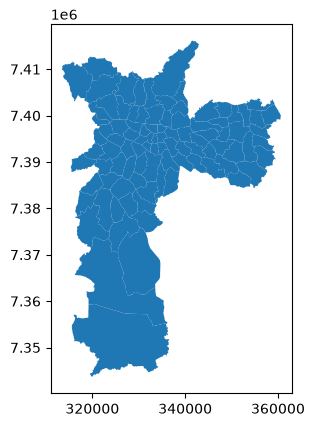

In [149]:
dados_mapa.plot()

## 🌐 O Sistema de Referência de Coordenadas (CRS)

### 📌 Por que o CRS é fundamental?
As formas geométricas contidas na coluna `geometry` de um objeto `GeoDataFrame` são, em sua essência matemática, apenas coleções de pontos e coordenadas em um espaço abstrato qualquer. O **CRS (Coordinate Reference System)** é a ferramenta que informa ao Python como traduzir esses números cartesianos em pontos físicos e localizações reais sobre a superfície do planeta Terra.

---

### 🔬 Gerenciamento do CRS no GeoPandas
Ao carregar arquivos geoespaciais nativos por meio da função `gpd.read_file()`, a biblioteca tenta identificar e importar o CRS automaticamente. No entanto, o GeoPandas pode encontrar problemas de conformidade caso o arquivo utilize metadados em formatos legados ou mais antigos. 

Para contornar isso e assegurar que as distâncias e contornos dos distritos sejam interpretados sem distorções, especificamos o padrão manualmente no código. Existem três abordagens principais documentadas para realizar essa atribuição no GeoPandas:

1. **Na inicialização da tabela:**
   `GeoDataFrame(..., crs="EPSG:31983")`
2. **Por atribuição direta de propriedade:**
   `gdf.crs = "EPSG:31983"`
3. **Por conversão/projeção explícita:**
   `gdf.to_crs("EPSG:31983")`

No nosso projeto, utilizamos o código **EPSG 31983** para sincronizar nossa matriz geométrica ao sistema **SIRGAS 2000 / UTM zone 23S**, o referencial cartográfico padrão e homologado da Prefeitura de São Paulo.


In [150]:
dados_mapa = dados_mapa.sort_values('ds_codigo')
dados_mapa


,ds_codigo,ds_subpref,ds_cd_sub,ds_sigla,ds_nome,geometry
38,1,MOOCA,25,ARA,AGUA RASA,"POLYGON ((341093.38 7391912.491, 341093.329 73..."
40,10,MOOCA,25,BRS,BRAS,"POLYGON ((333984.37 7396019.757, 333985.591 73..."
3,11,FREGUESIA-BRASILANDIA,03,BRL,BRASILANDIA,"POLYGON ((324895.091 7404257.969, 324893.588 7..."
52,12,BUTANTA,10,BUT,BUTANTA,"POLYGON ((322177.067 7393085.002, 322176.956 7..."
6,13,CASA VERDE-CACHOEIRINHA,04,CAC,CACHOEIRINHA,"POLYGON ((330950.659 7402181.997, 330944.935 7..."
...,...,...,...,...,...,...
10,92,VILA MARIA-VILA GUILHERME,07,VMD,VILA MEDEIROS,"POLYGON ((340579.417 7401672.553, 340579.493 7..."
47,93,VILA PRUDENTE,29,VPR,VILA PRUDENTE,"POLYGON ((341731.295 7388459.495, 341723.755 7..."
51,94,BUTANTA,10,VSO,VILA SONIA,"POLYGON ((320805.525 7390280.495, 320824.353 7..."
1,95,PIRITUBA-JARAGUA,02,SDO,SAO DOMINGOS,"POLYGON ((319854.036 7402894.086, 319864.99 74..."


In [151]:
distritos = distritos.sort_values('cod_ibge')
distritos


,cod_ibge,distritos,renda,quota,escolaridade,idade,mortalidade,txcresc,causasext,favel,denspop,F1,F2,Ranking
0,1,Água Rasa,1961,34.619999,7.6,32,13.860000,-1.84,52.980000,0.00,125.610001,1.519105,-0.705531,0.745250
9,2,Brás,1942,28.969999,7.0,30,13.640000,-4.48,120.669998,0.00,76.190002,0.255792,-0.361695,0.094064
10,3,Brasilândia,975,8.220000,5.8,22,22.000000,3.14,125.019997,16.60,112.059998,-3.410026,-0.046604,-1.883828
11,4,Butantã,2311,50.320000,8.4,31,18.129999,-1.60,44.730000,0.26,42.820000,1.878630,0.596856,1.111721
12,5,Cachoeirinha,1347,12.340000,6.2,23,15.710000,2.28,105.599998,17.42,105.919998,-2.251493,0.365884,-1.192495
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
91,92,Vila Medeiros,1405,19.760000,6.8,27,15.430000,-1.41,77.980003,2.49,188.929993,-0.222504,-1.738918,-0.347492
92,93,Vila Prudente,1755,32.080002,7.2,30,14.360000,-2.55,66.510002,7.43,101.440002,0.651970,-0.162769,0.337963
93,94,Vila Sônia,2970,41.410000,7.4,27,16.760000,-0.90,74.680000,14.93,80.120003,0.452520,1.057936,0.386055
94,95,São Domingos,2047,23.510000,6.8,26,14.300000,0.71,62.349998,8.55,72.919998,-0.262248,0.647456,-0.060650


In [152]:
from unidecode import unidecode


In [153]:
nomes_distritos = [unidecode(distrito).upper() for distrito in distritos['distritos']]
nomes_distritos


['AGUA RASA',
 'BRAS',
 'BRASILANDIA',
 'BUTANTA',
 'CACHOEIRINHA',
 'CAMBUCI',
 'CAMPO BELO',
 'CAMPO GRANDE',
 'CAMPO LIMPO',
 'CANGAIBA',
 'CAPAO REDONDO',
 'ALTO DE PINHEIROS',
 'CARRAO',
 'CASA VERDE',
 'CIDADE ADEMAR',
 'CIDADE DUTRA',
 'CIDADE LIDER',
 'CIDADE TIRADENTES',
 'CONSOLACAO',
 'CURSINO',
 'ERMELINO MATARAZZO',
 'FREGUESIA DO O',
 'ANHANGUERA',
 'GRAJAU',
 'GUAIANASES',
 'MOEMA',
 'IGUATEMI',
 'IPIRANGA',
 'ITAIM BIBI',
 'ITAIM PAULISTA',
 'ITAQUERA',
 'JABAQUARA',
 'JACANA',
 'ARICANDUVA',
 'JAGUARA',
 'JAGUARE',
 'JARAGUA',
 'JARDIM ANGELA',
 'JARDIM HELENA',
 'JARDIM PAULISTA',
 'JARDIM SAO LUIS',
 'JOSE BONIFACIO',
 'LAPA',
 'LIBERDADE',
 'ARTUR ALVIM',
 'LIMAO',
 'MANDAQUI',
 'MARSILAC',
 'MOOCA',
 'MORUMBI',
 'PARELHEIROS',
 'PARI',
 'PARQUE DO CARMO',
 'PEDREIRA',
 'PENHA',
 'BARRA FUNDA',
 'PERDIZES',
 'PERUS',
 'PINHEIROS',
 'PIRITUBA',
 'PONTE RASA',
 'RAPOSO TAVARES',
 'REPUBLICA',
 'RIO PEQUENO',
 'SARCOMA',
 'SANTA CECILIA',
 'BELA VISTA',
 'SANTANA',
 'S

In [154]:
distritos['nome_distrito'] = nomes_distritos


In [155]:
distritos_distintos = distritos['nome_distrito'].values != dados_mapa['ds_nome'].values
distritos_distintos.sum()


np.int64(1)

In [156]:
distritos[distritos_distintos]


,cod_ibge,distritos,renda,quota,escolaridade,idade,mortalidade,txcresc,causasext,favel,denspop,F1,F2,Ranking,nome_distrito
67,65,Sarcomã,1608,19.1,6.8,26,13.02,0.53,82.18,20.34,152.720001,-0.861934,-0.071781,-0.483928,SARCOMA


In [157]:
dados_mapa[distritos_distintos]


,ds_codigo,ds_subpref,ds_cd_sub,ds_sigla,ds_nome,geometry
72,68,IPIRANGA,13,SAC,SACOMA,"POLYGON ((338736.624 7387832.779, 338733.609 7..."


In [158]:
distritos.replace({'SARCOMA':'SACOMA', 'Sarcomã':'Sacoma'}, inplace = True)


,cod_ibge,distritos,renda,quota,escolaridade,idade,mortalidade,txcresc,causasext,favel,denspop,F1,F2,Ranking,nome_distrito
0,1,Água Rasa,1961,34.619999,7.6,32,13.860000,-1.84,52.980000,0.00,125.610001,1.519105,-0.705531,0.745250,AGUA RASA
9,2,Brás,1942,28.969999,7.0,30,13.640000,-4.48,120.669998,0.00,76.190002,0.255792,-0.361695,0.094064,BRAS
10,3,Brasilândia,975,8.220000,5.8,22,22.000000,3.14,125.019997,16.60,112.059998,-3.410026,-0.046604,-1.883828,BRASILANDIA
11,4,Butantã,2311,50.320000,8.4,31,18.129999,-1.60,44.730000,0.26,42.820000,1.878630,0.596856,1.111721,BUTANTA
12,5,Cachoeirinha,1347,12.340000,6.2,23,15.710000,2.28,105.599998,17.42,105.919998,-2.251493,0.365884,-1.192495,CACHOEIRINHA
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
91,92,Vila Medeiros,1405,19.760000,6.8,27,15.430000,-1.41,77.980003,2.49,188.929993,-0.222504,-1.738918,-0.347492,VILA MEDEIROS
92,93,Vila Prudente,1755,32.080002,7.2,30,14.360000,-2.55,66.510002,7.43,101.440002,0.651970,-0.162769,0.337963,VILA PRUDENTE
93,94,Vila Sônia,2970,41.410000,7.4,27,16.760000,-0.90,74.680000,14.93,80.120003,0.452520,1.057936,0.386055,VILA SONIA
94,95,São Domingos,2047,23.510000,6.8,26,14.300000,0.71,62.349998,8.55,72.919998,-0.262248,0.647456,-0.060650,SAO DOMINGOS


In [159]:
distritos[distritos_distintos]


,cod_ibge,distritos,renda,quota,escolaridade,idade,mortalidade,txcresc,causasext,favel,denspop,F1,F2,Ranking,nome_distrito
67,65,Sacoma,1608,19.1,6.8,26,13.02,0.53,82.18,20.34,152.720001,-0.861934,-0.071781,-0.483928,SACOMA


In [160]:
dados_completos = dados_mapa.merge(distritos, left_on = 'ds_nome', right_on = 'nome_distrito')
dados_completos


,ds_codigo,ds_subpref,ds_cd_sub,ds_sigla,ds_nome,geometry,cod_ibge,distritos,renda,quota,...,idade,mortalidade,txcresc,causasext,favel,denspop,F1,F2,Ranking,nome_distrito
0,1,MOOCA,25,ARA,AGUA RASA,"POLYGON ((341093.38 7391912.491, 341093.329 73...",1,Água Rasa,1961,34.619999,...,32,13.860000,-1.84,52.980000,0.00,125.610001,1.519105,-0.705531,0.745250,AGUA RASA
1,10,MOOCA,25,BRS,BRAS,"POLYGON ((333984.37 7396019.757, 333985.591 73...",2,Brás,1942,28.969999,...,30,13.640000,-4.48,120.669998,0.00,76.190002,0.255792,-0.361695,0.094064,BRAS
2,11,FREGUESIA-BRASILANDIA,03,BRL,BRASILANDIA,"POLYGON ((324895.091 7404257.969, 324893.588 7...",3,Brasilândia,975,8.220000,...,22,22.000000,3.14,125.019997,16.60,112.059998,-3.410026,-0.046604,-1.883828,BRASILANDIA
3,12,BUTANTA,10,BUT,BUTANTA,"POLYGON ((322177.067 7393085.002, 322176.956 7...",4,Butantã,2311,50.320000,...,31,18.129999,-1.60,44.730000,0.26,42.820000,1.878630,0.596856,1.111721,BUTANTA
4,13,CASA VERDE-CACHOEIRINHA,04,CAC,CACHOEIRINHA,"POLYGON ((330950.659 7402181.997, 330944.935 7...",5,Cachoeirinha,1347,12.340000,...,23,15.710000,2.28,105.599998,17.42,105.919998,-2.251493,0.365884,-1.192495,CACHOEIRINHA
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
91,92,VILA MARIA-VILA GUILHERME,07,VMD,VILA MEDEIROS,"POLYGON ((340579.417 7401672.553, 340579.493 7...",92,Vila Medeiros,1405,19.760000,...,27,15.430000,-1.41,77.980003,2.49,188.929993,-0.222504,-1.738918,-0.347492,VILA MEDEIROS
92,93,VILA PRUDENTE,29,VPR,VILA PRUDENTE,"POLYGON ((341731.295 7388459.495, 341723.755 7...",93,Vila Prudente,1755,32.080002,...,30,14.360000,-2.55,66.510002,7.43,101.440002,0.651970,-0.162769,0.337963,VILA PRUDENTE
93,94,BUTANTA,10,VSO,VILA SONIA,"POLYGON ((320805.525 7390280.495, 320824.353 7...",94,Vila Sônia,2970,41.410000,...,27,16.760000,-0.90,74.680000,14.93,80.120003,0.452520,1.057936,0.386055,VILA SONIA
94,95,PIRITUBA-JARAGUA,02,SDO,SAO DOMINGOS,"POLYGON ((319854.036 7402894.086, 319864.99 74...",95,São Domingos,2047,23.510000,...,26,14.300000,0.71,62.349998,8.55,72.919998,-0.262248,0.647456,-0.060650,SAO DOMINGOS


In [161]:
import matplotlib.pyplot as plt


(np.float64(311028.2445915086),
 np.float64(362979.62402979465),
 np.float64(7340122.141582586),
 np.float64(7419777.028684506))

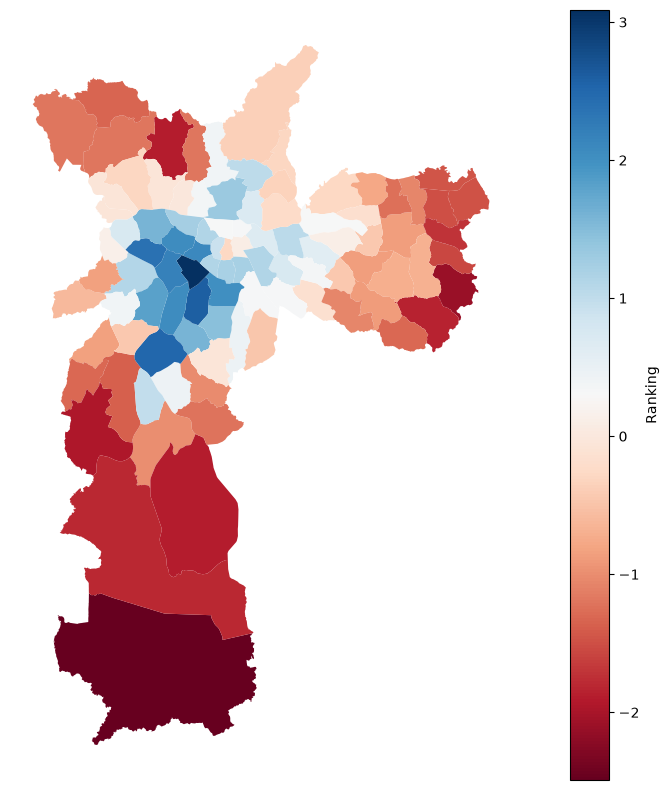

In [163]:
dados_completos.plot(column = 'Ranking', legend = True,
                     legend_kwds = {'label': 'Ranking', 'orientation':'vertical'},
                     cmap = 'RdBu', figsize = (15,10))
plt.axis('off')


In [164]:
dados_completos['coords'] = dados_completos['geometry'].apply(lambda x: x.representative_point().coords[0])


In [ ]:
dados_completos['coords'] = dados_completos['coords']
